In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install fairlearn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 5.5 MB/s eta 0:00:00


In [3]:
import fairlearn
from fairlearn.metrics import (
    MetricFrame,
    demographic_parity_difference,
    equalized_odds_difference
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score
)

In [4]:
import joblib

In [5]:
X_test = joblib.load(
    '/content/drive/MyDrive/credit-scoring-project/models/X_test.pkl'
)

y_test = joblib.load(
    '/content/drive/MyDrive/credit-scoring-project/models/y_test.pkl'
)

lgb_pred = joblib.load(
    '/content/drive/MyDrive/credit-scoring-project/models/lgb_pred.pkl'
)

In [6]:
sensitive_feature = X_test['REGION_RATING_CLIENT'].astype(int)

In [7]:
y_pred = (lgb_pred >= 0.5).astype(int)

In [8]:
print("Sensitive group distribution:")
print(sensitive_feature.value_counts())

Sensitive group distribution:
REGION_RATING_CLIENT
2    45353
3     9708
1     6442
Name: count, dtype: int64


In [9]:
from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    false_positive_rate,
    false_negative_rate
)

In [10]:
mf = MetricFrame(
    metrics={
        'accuracy': accuracy_score,
        'selection_rate': selection_rate,
        'false_positive_rate': false_positive_rate,
        'false_negative_rate': false_negative_rate
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sensitive_feature
)

In [11]:
print("Per-group metrics:")
print(mf.by_group)

Per-group metrics:
                      accuracy  selection_rate  false_positive_rate  \
REGION_RATING_CLIENT                                                  
1                     0.884197        0.108196             0.092849   
2                     0.763698        0.251295             0.221749   
3                     0.660074        0.392048             0.349421   

                      false_negative_rate  
REGION_RATING_CLIENT                       
1                                0.580858  
2                                0.405398  
3                                0.263109  


In [12]:
print("\nOverall metrics:")
print(mf.overall)


Overall metrics:
accuracy               0.759963
selection_rate         0.258524
false_positive_rate    0.227263
false_negative_rate    0.385498
dtype: float64


In [13]:
print("\nDifference (max - min across groups):")
print(mf.difference())


Difference (max - min across groups):
accuracy               0.224123
selection_rate         0.283852
false_positive_rate    0.256572
false_negative_rate    0.317749
dtype: float64


In [14]:
dpd = demographic_parity_difference(
    y_test,
    y_pred,
    sensitive_features=sensitive_feature
)

eod = equalized_odds_difference(
    y_test,
    y_pred,
    sensitive_features=sensitive_feature
)

print(f"\nDemographic Parity Difference: {dpd:.4f}")
print(f"Equalized Odds Difference: {eod:.4f}")
print("(Closer to 0 = fairer model)")


Demographic Parity Difference: 0.2839
Equalized Odds Difference: 0.3177
(Closer to 0 = fairer model)


In [15]:
with open(
    '/content/drive/MyDrive/credit-scoring-project/reports/fairness_results.txt',
    'w'
) as f:
    f.write("Demographic Parity Difference: 0.2839\n")
    f.write("Equalized Odds Difference: 0.3177\n")

print("Saved")

Saved


In [16]:
from fairlearn.reductions import ExponentiatedGradient, DemographicParity
from sklearn.metrics import roc_auc_score

In [17]:
import lightgbm as lgb

In [18]:
base_estimator = lgb.LGBMClassifier(
    n_estimators=200,
    verbose=-1,
    random_state=42
)

constraint = DemographicParity()

In [19]:
fair_model = ExponentiatedGradient(
    estimator=base_estimator,
    constraints=constraint,
    eps=0.05
)

In [20]:
import joblib

X_train = joblib.load(
    '/content/drive/MyDrive/credit-scoring-project/models/X_train.pkl'
)

y_train = joblib.load(
    '/content/drive/MyDrive/credit-scoring-project/models/y_train.pkl'
)

In [21]:
print(X_train.shape)
print(y_train.shape)

(246008, 89)
(246008,)


In [22]:
fair_model.fit(
    X_train,
    y_train,
    sensitive_features=X_train['REGION_RATING_CLIENT']
)

ExponentiatedGradient(constraints=<fairlearn.reductions._moments.utility_parity.DemographicParity object at 0x7ac59a47ff80>,
                      eps=0.05,
                      estimator=LGBMClassifier(n_estimators=200,
                                               random_state=42, verbose=-1),
                      nu=np.float64(0.000270876092202863))

In [23]:
fair_pred_prob = fair_model.predict(X_test)

fair_pred = (fair_pred_prob >= 0.5).astype(int)

In [24]:
unconstrained_auc = roc_auc_score(
    y_test,
    lgb_pred
)

fair_dpd = demographic_parity_difference(
    y_test,
    fair_pred,
    sensitive_features=sensitive_feature
)

unconstrained_dpd = demographic_parity_difference(
    y_test,
    y_pred,
    sensitive_features=sensitive_feature
)

In [25]:
print(
    f"Unconstrained → AUC: {unconstrained_auc:.4f}, "
    f"DPD: {unconstrained_dpd:.4f}"
)

print(
    f"Fair-constrained → DPD: {fair_dpd:.4f}"
)

print(
    f"Fairness improvement: "
    f"{unconstrained_dpd - fair_dpd:.4f}"
)

Unconstrained → AUC: 0.7638, DPD: 0.2839
Fair-constrained → DPD: 0.0096
Fairness improvement: 0.2743


In [26]:
from fairlearn.reductions import ExponentiatedGradient, DemographicParity
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
import pandas as pd
import matplotlib.pyplot as plt

# Sensitive feature — region rating as your geography proxy
sensitive_train = X_train['REGION_RATING_CLIENT'].astype(int)
sensitive_test  = X_test['REGION_RATING_CLIENT'].astype(int)

# Unconstrained baseline numbers (already trained model: lgb_m)
baseline_auc = roc_auc_score(y_test, lgb_pred)
baseline_dpd = demographic_parity_difference(y_test, y_pred, sensitive_features=sensitive_test)
baseline_eod = equalized_odds_difference(y_test, y_pred, sensitive_features=sensitive_test)

print(f"Baseline (unconstrained): AUC={baseline_auc:.4f}, DPD={baseline_dpd:.4f}, EOD={baseline_eod:.4f}")

# Epsilon values to sweep — smaller eps = stricter fairness constraint
eps_values = [0.005, 0.01, 0.02, 0.03, 0.05, 0.08, 0.10, 0.15, 0.20]

tradeoff_results = []

for eps in eps_values:
    print(f"\nTraining with eps={eps} ...")

    base_estimator = lgb.LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        verbose=-1
    )

    fair_model = ExponentiatedGradient(
        estimator=base_estimator,
        constraints=DemographicParity(),
        eps=eps
    )

    fair_model.fit(X_train, y_train, sensitive_features=sensitive_train)

    # ExponentiatedGradient's predict() returns hard 0/1 labels by default
    fair_pred = fair_model.predict(X_test)

    auc = roc_auc_score(y_test, fair_pred)
    dpd = demographic_parity_difference(y_test, fair_pred, sensitive_features=sensitive_test)
    eod = equalized_odds_difference(y_test, fair_pred, sensitive_features=sensitive_test)

    tradeoff_results.append({
        'eps': eps,
        'AUC': auc,
        'DPD': dpd,
        'EOD': eod
    })

    print(f"  AUC={auc:.4f}, DPD={dpd:.4f}, EOD={eod:.4f}")

# Convert to dataframe
tradeoff_df = pd.DataFrame(tradeoff_results)
print("\n=== Full results ===")
print(tradeoff_df)

Baseline (unconstrained): AUC=0.7638, DPD=0.2839, EOD=0.3177

Training with eps=0.005 ...
  AUC=0.5084, DPD=0.0053, EOD=0.0234

Training with eps=0.01 ...
  AUC=0.5084, DPD=0.0053, EOD=0.0234

Training with eps=0.02 ...
  AUC=0.5089, DPD=0.0053, EOD=0.0210

Training with eps=0.03 ...
  AUC=0.5093, DPD=0.0067, EOD=0.0300

Training with eps=0.05 ...
  AUC=0.5093, DPD=0.0067, EOD=0.0300

Training with eps=0.08 ...
  AUC=0.5089, DPD=0.0063, EOD=0.0281

Training with eps=0.1 ...
  AUC=0.5089, DPD=0.0063, EOD=0.0281

Training with eps=0.15 ...
  AUC=0.5085, DPD=0.0053, EOD=0.0234

Training with eps=0.2 ...
  AUC=0.5084, DPD=0.0050, EOD=0.0225

=== Full results ===
     eps       AUC       DPD       EOD
0  0.005  0.508367  0.005253  0.023408
1  0.010  0.508367  0.005253  0.023408
2  0.020  0.508861  0.005304  0.021044
3  0.030  0.509277  0.006696  0.029963
4  0.050  0.509277  0.006696  0.029963
5  0.080  0.508865  0.006283  0.028090
6  0.100  0.508865  0.006283  0.028090
7  0.150  0.508459  0

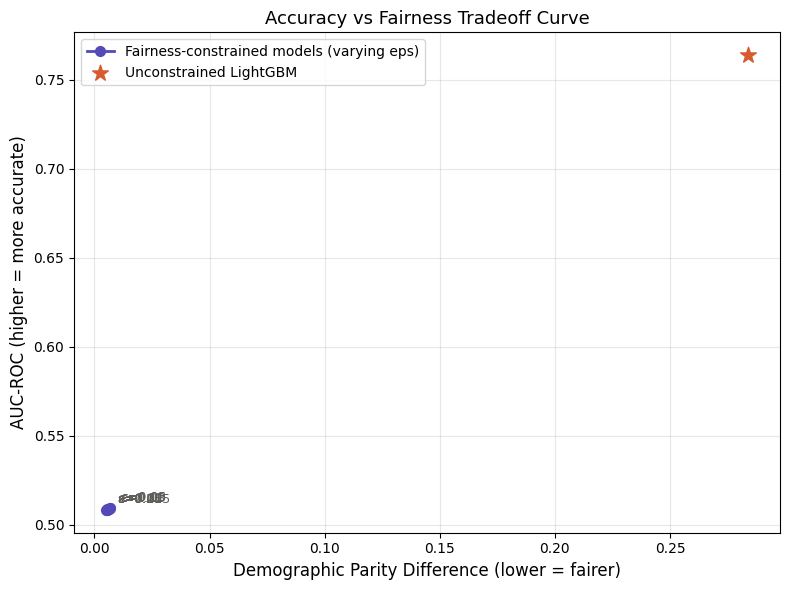

In [33]:
fig, ax = plt.subplots(figsize=(8, 6))

tradeoff_sorted = tradeoff_df.sort_values('DPD')

ax.plot(tradeoff_sorted['DPD'], tradeoff_sorted['AUC'],
        'o-', color='#534AB7', linewidth=2, markersize=7,
        label='Fairness-constrained models (varying eps)')

# Mark unconstrained baseline
ax.scatter([baseline_dpd], [baseline_auc],
           s=140, color='#D85A30', zorder=5, marker='*',
           label='Unconstrained LightGBM')

# Annotate eps values
for _, row in tradeoff_sorted.iterrows():
    ax.annotate(f"ε={row['eps']}",
                (row['DPD'], row['AUC']),
                textcoords="offset points", xytext=(8, 5),
                fontsize=9, color='#5F5E5A')

ax.set_xlabel('Demographic Parity Difference (lower = fairer)', fontsize=12)
ax.set_ylabel('AUC-ROC (higher = more accurate)', fontsize=12)
ax.set_title('Accuracy vs Fairness Tradeoff Curve', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/credit-scoring-project/reports/fairness_tradeoff_full.png',
    dpi=150
)
plt.show()

In [27]:
!pip install fairlearn -q

In [28]:
import matplotlib.pyplot as plt

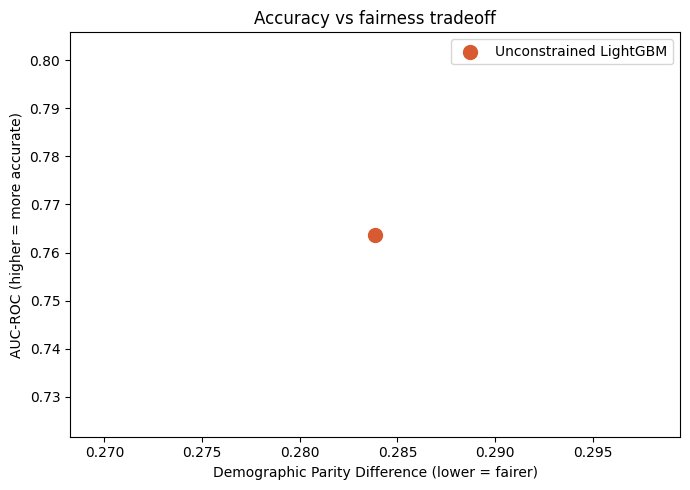

In [29]:
plt.figure(figsize=(7,5))

plt.scatter(
    [unconstrained_dpd],
    [unconstrained_auc],
    s=100,
    color='#D85A30',
    zorder=5,
    label='Unconstrained LightGBM'
)

plt.xlabel('Demographic Parity Difference (lower = fairer)')
plt.ylabel('AUC-ROC (higher = more accurate)')
plt.title('Accuracy vs fairness tradeoff')

plt.legend()

plt.tight_layout()

plt.savefig(
    '/content/drive/MyDrive/credit-scoring-project/reports/fairness_tradeoff.png',
    dpi=150
)

plt.show()

In [30]:
import os

print(
    os.path.exists(
        '/content/drive/MyDrive/credit-scoring-project/reports/fairness_tradeoff.png'
    )
)

True


In [32]:
print(type(tradeoff_df))
print(tradeoff_df.head())

<class 'pandas.core.frame.DataFrame'>
     eps       AUC       DPD       EOD
0  0.005  0.508367  0.005253  0.023408
1  0.010  0.508367  0.005253  0.023408
2  0.020  0.508861  0.005304  0.021044
3  0.030  0.509277  0.006696  0.029963
4  0.050  0.509277  0.006696  0.029963
